# Ecommerce Customers - Lab 6 Task Solution

This notebook applies the same workflow used in the lab to the **Ecommerce Customers** dataset.

## 1) Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2) Load the dataset into a DataFrame

In [2]:
# Load the dataset
ecom = pd.read_csv('Ecommerce_Customers.csv')

# Show the first 5 rows
ecom.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 3) Explore the data

In [3]:
# Basic structure of the dataset
ecom.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [4]:
# Statistical summary of numeric columns
ecom.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
# Column names
ecom.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

In [6]:
# Check the shape of the dataset
ecom.shape

(500, 8)

## 4) Perform basic data cleaning if needed

In [7]:
# Check for missing values
ecom.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [8]:
# Check for duplicate rows
ecom.duplicated().sum()

np.int64(0)

In [9]:
# Since this dataset has no missing values and no duplicate rows,
# no major cleaning is required.
# We will keep the dataset as is.
ecom_clean = ecom.copy()
ecom_clean.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## 5) Apply feature engineering (if applicable)

For this dataset, no complex feature engineering is necessary for the baseline model.
The useful predictors are already available as numeric columns. The text columns (`Email`, `Address`, `Avatar`) are not suitable for the same simple regression model used in the lab, so we exclude them from modeling.

We will also create one simple optional feature to represent overall engagement, just for illustration.

In [10]:
# Optional simple engineered feature
ecom_clean['Total Time Spent'] = ecom_clean['Time on App'] + ecom_clean['Time on Website']

# Preview relevant columns
ecom_clean[['Time on App', 'Time on Website', 'Total Time Spent', 'Yearly Amount Spent']].head()

,Time on App,Time on Website,Total Time Spent,Yearly Amount Spent
0,12.655651,39.577668,52.233319,587.951054
1,11.109461,37.268959,48.378420,392.204933
2,11.330278,37.110597,48.440875,487.547505
3,13.717514,36.721283,50.438796,581.852344
4,12.795189,37.536653,50.331842,599.406092


## 6) Visual exploration

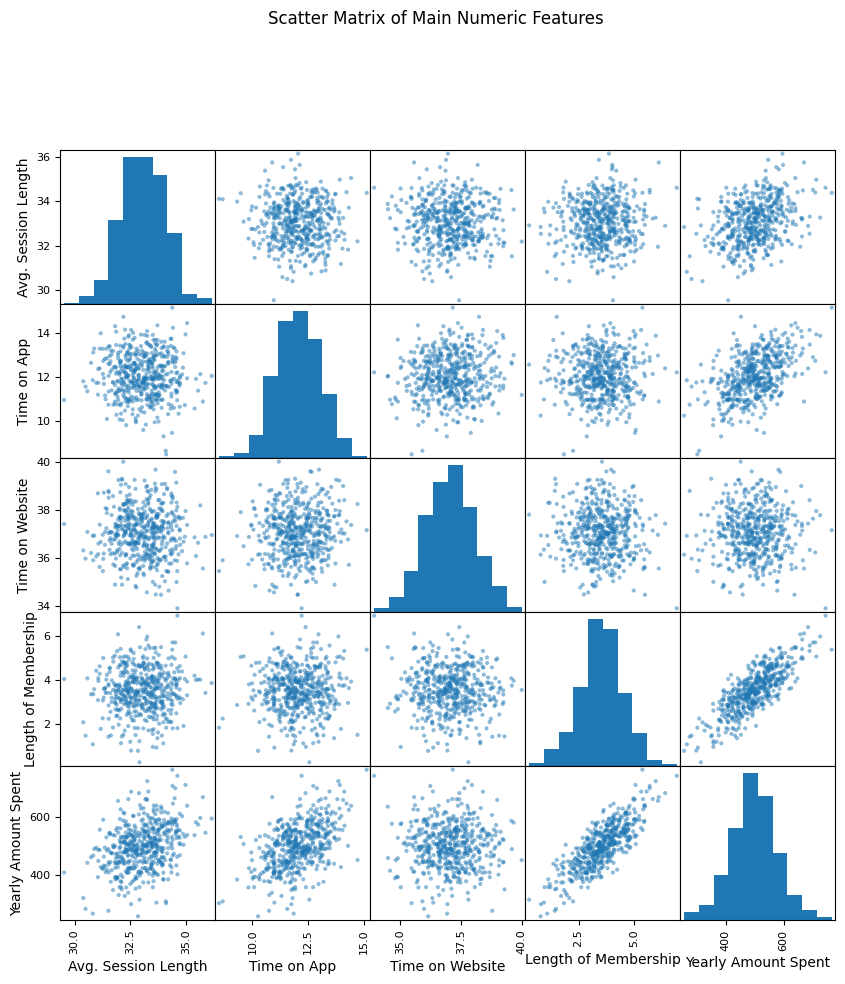

In [11]:
# Scatter matrix for the main numeric columns
from pandas.plotting import scatter_matrix

scatter_matrix(
    ecom_clean[['Avg. Session Length',
                'Time on App',
                'Time on Website',
                'Length of Membership',
                'Yearly Amount Spent']],
    figsize=(10, 10),
    diagonal='hist'
)
plt.suptitle('Scatter Matrix of Main Numeric Features', y=1.02)
plt.show()

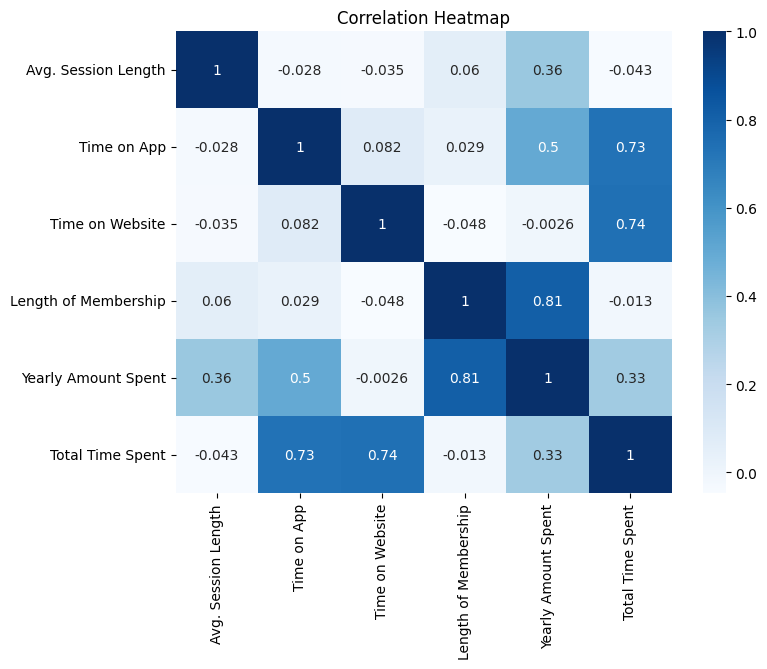

In [12]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(ecom_clean.select_dtypes(include='number').corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

## 7) Prepare the data for modeling

To stay consistent with the lab, we will use **Linear Regression**.
We will use the original main numeric features as predictors and `Yearly Amount Spent` as the target.

In [13]:
# Features (X) and target (y)
X = ecom_clean[['Avg. Session Length',
                'Time on App',
                'Time on Website',
                'Length of Membership']]

y = ecom_clean['Yearly Amount Spent']

X.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308


In [14]:
from sklearn.model_selection import train_test_split

# Same split style used in the lab
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

X_train.shape, X_test.shape

((300, 4), (200, 4))

## 8) Train the model

In [15]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# Model intercept
print('Intercept:', lm.intercept_)

# Model coefficients
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

Intercept: -1045.1152168245749


,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


## 9) Make predictions

In [17]:
predictions = lm.predict(X_test)

predictions[:10]

array([454.37723888, 404.73920978, 410.6595358 , 591.19506767,
       590.48315271, 548.36329288, 576.56306627, 714.33230591,
       473.38888194, 546.20504453])

In [18]:
# Compare actual vs predicted values
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

results.head(10)

,Actual,Predicted
0,452.315675,454.377239
1,401.033135,404.739210
2,410.069611,410.659536
3,599.406092,591.195068
4,586.155870,590.483153
5,535.480775,548.363293
6,588.712606,576.563066
7,712.396327,714.332306
8,462.897636,473.388882
9,532.724805,546.205045


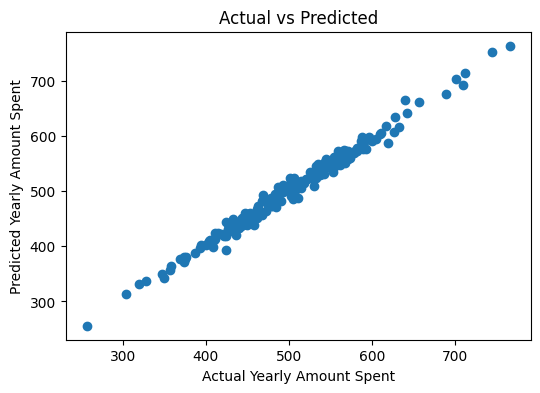

In [19]:
# Scatter plot of actual vs predicted values
plt.figure(figsize=(6,4))
plt.scatter(y_test, predictions)
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted')
plt.show()

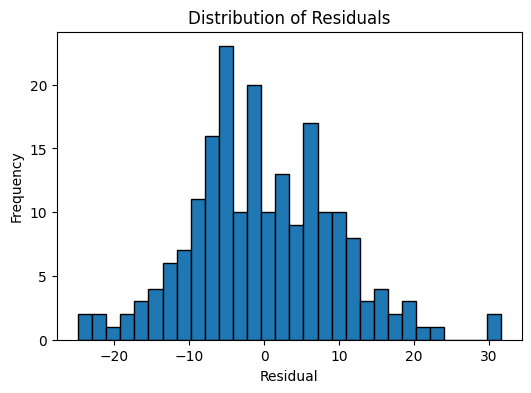

In [20]:
# Distribution of residuals
residuals = y_test - predictions

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

## 10) Evaluate the model performance

In [21]:
from sklearn import metrics

mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R^2:', r2)

MAE: 7.74267128583873
MSE: 93.83297800820075
RMSE: 9.68674238370159
R^2: 0.9855061240024658
